In [1]:
# Plot data Rijkswaterstaat stations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [3]:
nc_waterlevel = r'data\Waterlevel_Scheveningen.nc'
with xr.open_dataset(nc_waterlevel) as ds_tmp:
    ds_waterlevel = ds_tmp.load()  # Loads all data into memory

ds_waterlevel # print the variables in ds_waterlevel

<xarray.Dataset> Size: 492kB
Dimensions:            (t: 17568)
Coordinates:
  * t                  (t) datetime64[ns] 141kB 2024-12-01 ... 2025-04-01T23:...
Data variables:
    waterlevel         (t) float64 141kB -26.0 -22.0 -16.0 ... -49.0 -53.0 -57.0
    waterlevel_kwlcod  (t) float64 141kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    waterlevel_rkssta  (t) <U1 70kB 'G' 'G' 'G' 'G' 'G' ... 'O' 'O' 'O' 'O' 'O'

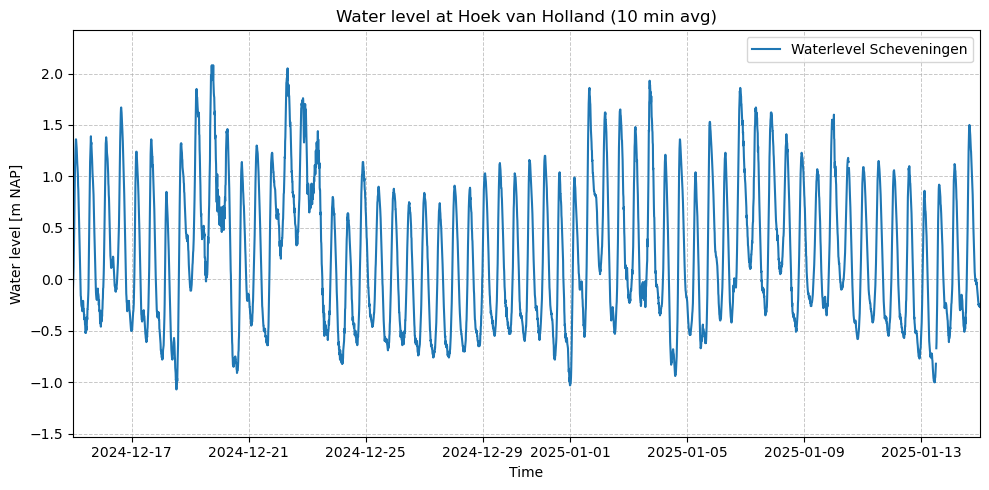

In [ ]:
# Plot waterlevel data
fig, ax = plt.subplots(figsize=(10, 5))

# Plot water level (convert cm → m)
ax.plot(ds_waterlevel.t, ds_waterlevel.waterlevel / 100, 
        label='Waterlevel Scheveningen', color='tab:blue')

# Axes and labels
ax.set_xlim(pd.Timestamp('2024-12-15'), pd.Timestamp('2025-01-15'))
ax.set_xlabel('Time')
ax.set_ylabel('Water level [m NAP]')
ax.tick_params(axis='y')

# Grid, title, legend
ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_title('Water level at Scheveningen (10 min avg)')
ax.legend(loc='upper right')

fig.tight_layout()
plt.show()

In [7]:
nc_waves = r'data\Waves_Hollandse_Kust_Zuid_A.nc'
with xr.open_dataset(nc_waves) as ds_tmp:
    ds_waves = ds_tmp.load()  # Loads all data into memory
ds_waves # print the variables in ds_waves

<xarray.Dataset> Size: 2MB
Dimensions:  (t: 17568)
Coordinates:
  * t        (t) datetime64[ns] 141kB 2024-12-01 ... 2025-04-01T23:50:00
Data variables: (12/13)
    H1_10th  (t) float64 141kB 94.0 100.0 100.0 93.0 ... 91.0 89.0 87.0 92.0
    H1_3rd   (t) float64 141kB 75.0 81.0 82.0 77.0 77.0 ... 74.0 74.0 71.0 73.0
    H1_50th  (t) float64 141kB 111.0 119.0 119.0 112.0 ... 105.0 101.0 110.0
    HTE3     (t) float64 141kB 33.0 37.0 37.0 33.0 34.0 ... 15.0 17.0 16.0 15.0
    Hm0      (t) float64 141kB 76.0 82.0 83.0 78.0 79.0 ... 73.0 73.0 70.0 71.0
    Hmax     (t) float64 141kB 119.0 127.0 127.0 122.0 ... 109.0 109.0 122.0
    ...       ...
    TE0      (t) float64 141kB 23.0 26.0 28.0 28.0 32.0 ... 26.0 28.0 29.0 28.0
    TE3      (t) float64 141kB 67.0 84.0 87.0 68.0 71.0 ... 14.0 18.0 17.0 15.0
    TH1_3rd  (t) float64 141kB 4.7 4.7 4.7 4.7 4.4 4.6 ... 4.1 4.3 4.3 4.3 4.3
    Tm02     (t) float64 141kB 4.1 4.1 4.1 4.0 3.9 4.0 ... 3.6 3.6 3.7 3.6 3.6
    Tm02_M   (t) float64 141kB 33.0 34.0 34.0 32.0 32.0 ... 30.0 30.0 30.0 30.0
    Tmax     (t) float64 141kB 8.9 12.9 12.9 8.6 9.6 9.7 ... 7.1 7.4 7.8 7.8 8.2

<Figure size 1000x500 with 0 Axes>

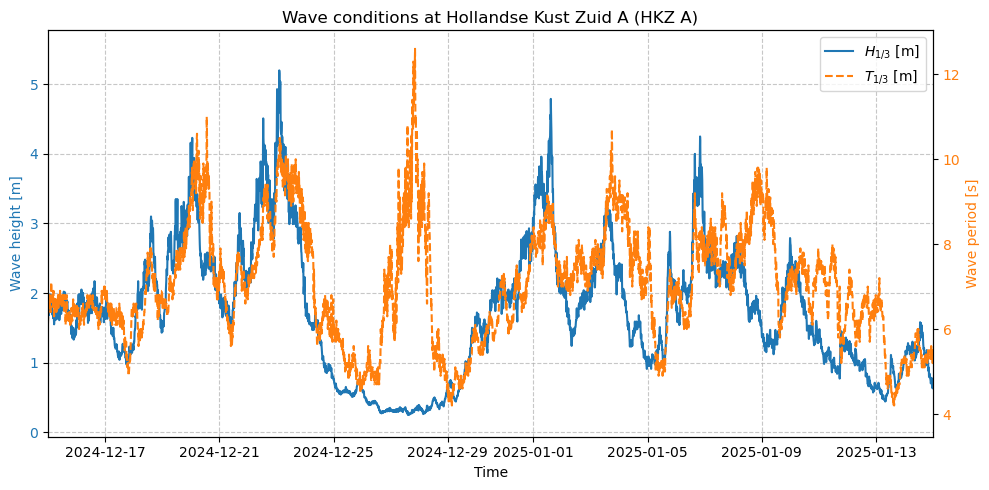

In [8]:
# Plot wave data
plt.figure(figsize=(10, 5))

# Primary axis (left one)
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(ds_waves.t, ds_waves.H1_3rd/100, label=r'$H_{1/3}$ [m]', color='tab:blue')
ax1.set_xlim(pd.Timestamp('2024-12-15'), pd.Timestamp('2025-01-15'))
ax1.set_xlabel('Time')
ax1.set_ylabel('Wave height [m]', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle='--', alpha=0.7)

# Secondary axis (right one)
ax2 = ax1.twinx()
ax2.plot(ds_waves.t, ds_waves.T1_3rd, label=r'$T_{1/3}$ [m]', color='tab:orange', linestyle='--')
ax2.set_ylabel('Wave period [s]', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Title and legend
plt.title('Wave conditions at Hollandse Kust Zuid A (HKZ A)')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.show()
